В этом блокноте мы исследуем важные концепции в машинном обучении, связанные с обучением нейронных сетей: недообучение и переобучение. Мы продемонстрируем, как эти проблемы проявляются, и изучим методы борьбы с переобучением, такие как Dropout и L2-регуляризация. Мы будем использовать датасет Fashion MNIST для наглядной демонстрации этих концепций.  Особое внимание уделим анализу кривых обучения и оценке качества моделей на тестовых данных.

### Импортируем данные и необходимые библиотеки

In [1]:
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

Будем использовать лишь фрагмент из всего набора данных, чтобы сократить временные затраты на обучение моделей.

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train[:5000]
X_test = X_test[:1000]
y_train = y_train[:5000]
y_test = y_test[:1000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Данные — значения интенсивностей пикселей и лежат в пределах $[0,255]$. "Распрямим" и масштабируем, чтобы получить значения из отрезка $[0,1]$.

In [3]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

Задача — многоклассовая классификация, поэтому произведем `one-hot` кодирование откликов.

In [4]:
y_train = np.eye(10)[y_train]

### Базовая модель

Построим самую простую модель: каждому классу ставим в соответствие один нейрон.
* Активация — `softmax`
* Оптимизатор — `adam`
* Лосс — `categorical_crossentropy`
* Метрика — `accuracy`
* Число эпох обучения — `10`
* `batch_size=256`
* `validation_split=0.2`


In [5]:
base_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(10, activation='softmax')
])

base_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history = base_model.fit(X_train, y_train,
                                   epochs=10,
                                   batch_size=256,
                                   validation_split=0.2,
                                   verbose=1)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2099 - loss: 2.1131 - val_accuracy: 0.6030 - val_loss: 1.4221
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6107 - loss: 1.3452 - val_accuracy: 0.6940 - val_loss: 1.0354
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6886 - loss: 1.0320 - val_accuracy: 0.7350 - val_loss: 0.8772
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7225 - loss: 0.9245 - val_accuracy: 0.7590 - val_loss: 0.7881
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7551 - loss: 0.8181 - val_accuracy: 0.7760 - val_loss: 0.7335
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7491 - loss: 0.7933 - val_accuracy: 0.7760 - val_loss: 0.6906
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7583 - loss: 0.7413 - val_accuracy: 0.7880 - val_loss: 0.6611
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7711 - loss: 0.7109 - val_accuracy: 0.7880 - val_lo

График лосса для `train` и `validation`

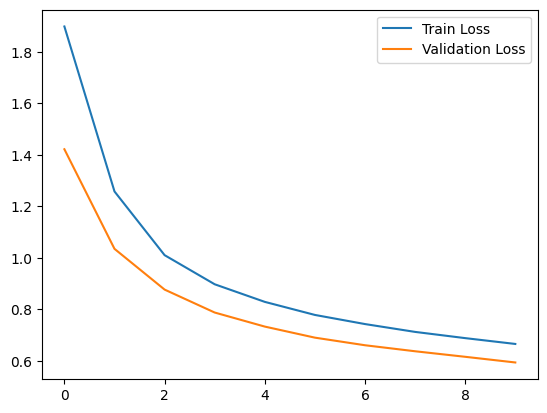

In [6]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

Что можно сказать по графику?

Оценим модель на тестовых данных

In [7]:
predictions_logits = base_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


0.776

Увеличим число эпох обучения до 30

In [8]:
base_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(10, activation='softmax')
])

base_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history = base_model.fit(X_train, y_train,
                                   epochs=30,
                                   batch_size=256,
                                   validation_split=0.2,
                                   verbose=0)

Графики лосса

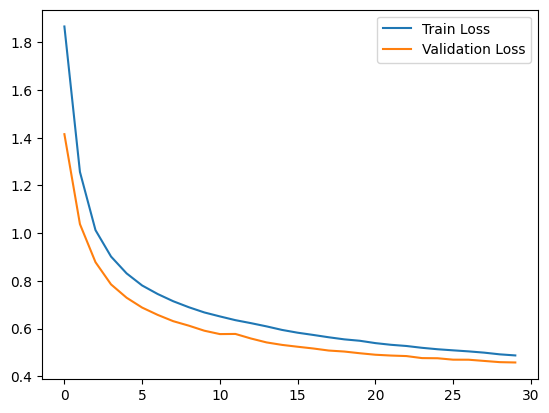

In [9]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

Что можно сказать по графику?

Оценим модель на тестовых данных

In [10]:
predictions_logits = base_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


0.817

### Усложняем модель

Очевидно, предыдущая модель слишком простая, хотя на деле не так плоха. Изменим архитектуру:

* Скрытые слои со следующим числом нейронов: `(1024, 512, 256)`. Активация — `relu`
* Установим `verbose=1` в методе `.fit()`, чтобы остлеживать прогресс
* Остальные параметры без изменений

In [11]:
overfit_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

overfit_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history = overfit_model.fit(X_train, y_train,
                          epochs=30,
                          batch_size=256,
                          validation_split=0.2,
                          verbose=1)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.4732 - loss: 1.4738 - val_accuracy: 0.7050 - val_loss: 0.7592
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7526 - loss: 0.6795 - val_accuracy: 0.8410 - val_loss: 0.4547
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8109 - loss: 0.5286 - val_accuracy: 0.8480 - val_loss: 0.4399
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8413 - loss: 0.4541 - val_accuracy: 0.8590 - val_loss: 0.4164
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8626 - loss: 0.3835 - val_accuracy: 0.8530 - val_loss: 0.3886
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.8777 - loss: 0.3595 - val_accuracy: 0.8570 - val_loss: 0.3956
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.8738 - loss: 0.3425 - val_accuracy: 0.8750 - val_loss: 0.3619
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8856 - loss: 0.3169 - val_accuracy: 0.8790 -

График лоссов

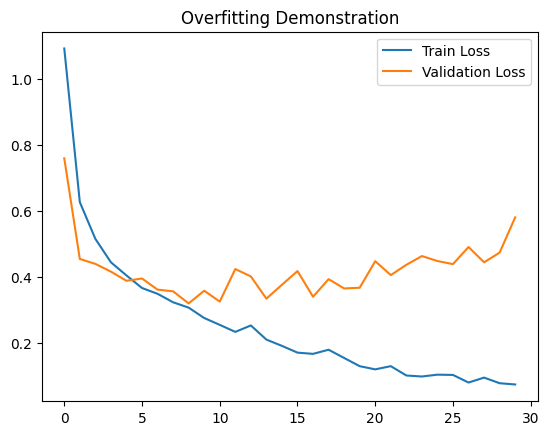

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Overfitting Demonstration')
plt.legend()
plt.show()

Что можно сказать, глядя на графики лоссов? А если еще увеличить число эпох?

Оценка на тесте

In [13]:
predictions_logits = overfit_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


0.826

### Регуляризация

Для борьбы с переобучением часто используют Dropout и регуляризацию. Dropout случайным образом "выключает" часть нейронов во время обучения, что заставляет сети "перераспределять" обязанности нейронов и не слишком полагаться на конкретные нейроны. Регуляризация добавляет штраф к функции потерь за большие значения весов, что препятствует сети слишком сильно подстраиваться под тренировочные данные.

In [14]:
regularized_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(512, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

regularized_model.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

history = regularized_model.fit(X_train, y_train,
                          epochs=30,
                          batch_size=256,
                          validation_split=0.2,
                          verbose=1)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.4214 - loss: 10.3971 - val_accuracy: 0.7460 - val_loss: 7.0994
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7230 - loss: 6.5601 - val_accuracy: 0.7990 - val_loss: 4.7071
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7734 - loss: 4.3890 - val_accuracy: 0.8260 - val_loss: 3.2505
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7872 - loss: 3.0845 - val_accuracy: 0.8350 - val_loss: 2.3703
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8094 - loss: 2.2984 - val_accuracy: 0.8310 - val_loss: 1.8633
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8081 - loss: 1.8371 - val_accuracy: 0.8560 - val_loss: 1.5055
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8121 - loss: 1.5196 - val_accuracy: 0.8400 - val_loss: 1.2977
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8288 - loss: 1.3033 - val_accuracy: 0.8480 - 

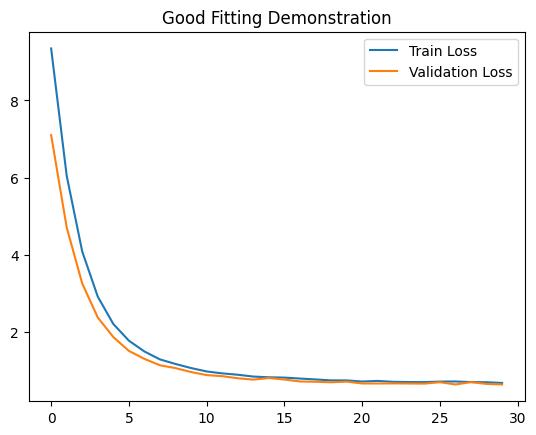

In [15]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Good Fitting Demonstration')
plt.legend()
plt.show()

In [16]:
predictions_logits = regularized_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


0.824

### Больше данных

Объем данных существенно влияет на обучение и качество сети. Возьмем весь набор данных и обучим на нем самую простую и самую сложную из рассмотренных моделей.

In [17]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0
y_train = np.eye(10)[y_train]

#### Маленькая модель

In [18]:
small_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(10, activation='softmax')
])

small_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history = small_model.fit(X_train, y_train,
                                   epochs=30,
                                   batch_size=256,
                                   validation_split=0.2,
                                   verbose=0)

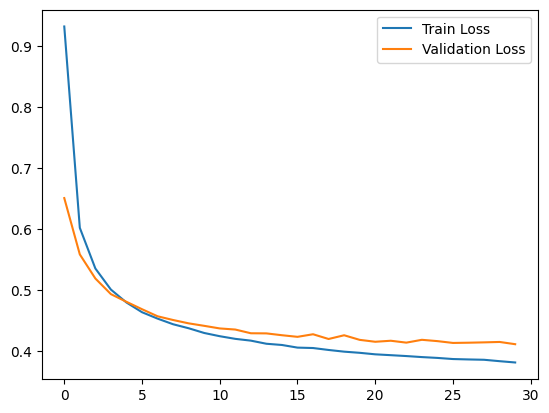

In [19]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [20]:
predictions_logits = small_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.8467

Видно, что дальнейшее увеличение данных при данной архитектуре дает некоторый прирост метрики, но, похоже мы выжали из этой модели максимум.

#### Большая модель

Возьмем сразу не очень большое число эпох, например, 10

In [21]:
big_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

big_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history = big_model.fit(X_train, y_train,
                          epochs=10,
                          batch_size=256,
                          validation_split=0.2,
                          verbose=1)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.7458 - loss: 0.7248 - val_accuracy: 0.8547 - val_loss: 0.4081
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.8615 - loss: 0.3756 - val_accuracy: 0.8488 - val_loss: 0.4068
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.8769 - loss: 0.3286 - val_accuracy: 0.8790 - val_loss: 0.3376
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.8865 - loss: 0.3031 - val_accuracy: 0.8813 - val_loss: 0.3271
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.8958 - loss: 0.2783 - val_accuracy: 0.8778 - val_loss: 0.3550
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.9021 - loss: 0.2655 - val_accuracy: 0.8862 - val_loss: 0.3219
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9088 - loss: 0.2468 - val_accuracy: 0.8878 - val_loss: 0.3149
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.9098 - loss: 0.2368 -

In [22]:
predictions_logits = big_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


0.8825

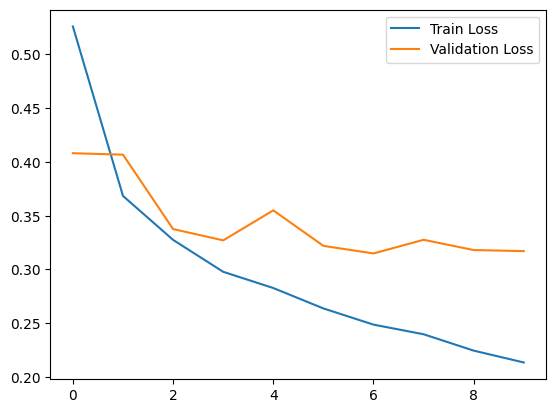

In [23]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()